In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
import mysql.connector

# Create connection
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Ayaan@2002",
    database="retail_dataset"
)

# Check connection
if conn.is_connected():
    print("Connected to MySQL database")

query = """
SELECT * FROM retail_data
"""
df=pd.read_sql(query,conn)
df.head()

Connected to MySQL database


C:\Users\ASUS\AppData\Local\Temp\ipykernel_17668\3803838651.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(query,conn)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,10001,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2023-01-05 10:15:00,2.55,17850,United Kingdom
1,10001,71053,WHITE METAL LANTERN,6,2023-01-05 10:15:00,3.39,17850,United Kingdom
2,10002,84406B,CREAM CUPID HEARTS COAT HANGER,8,2023-01-06 11:20:00,2.75,13047,France
3,10003,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2023-01-07 09:12:00,3.39,12583,Germany
4,10004,22752,SET 7 BABUSHKA NESTING BOXES,2,2023-01-08 14:05:00,7.65,13748,Spain


**Monthly Revenue Trend**

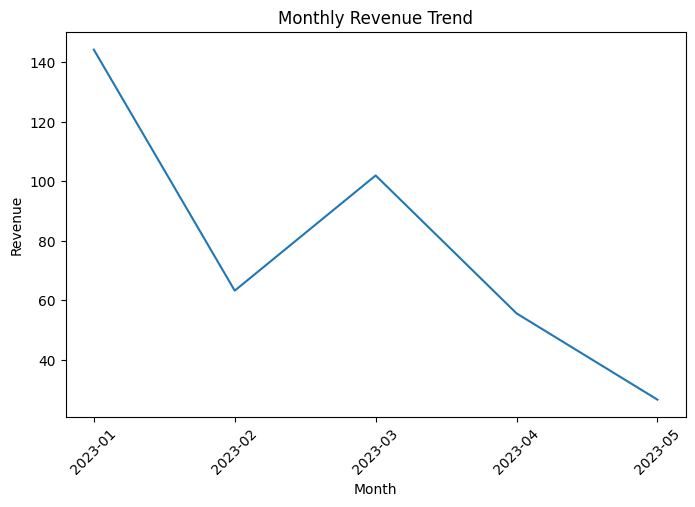

In [13]:
df['InvoiceDate']=pd. to_datetime(df['InvoiceDate'])
df['Revenue']=df['Quantity']*df['UnitPrice']
df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_revenue = df.groupby('Month')['Revenue'].sum().reset_index()
monthly_revenue['Month'] = monthly_revenue['Month'].astype(str)


plt.figure(figsize=(8,5))
sns.lineplot(data=monthly_revenue, x='Month', y='Revenue')
plt.title("Monthly Revenue Trend")
plt.xticks(rotation=45)
plt.show()

**Top 10 Products**

C:\Users\ASUS\AppData\Local\Temp\ipykernel_17668\169568356.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_product,y='Description',x='Revenue',palette='viridis')


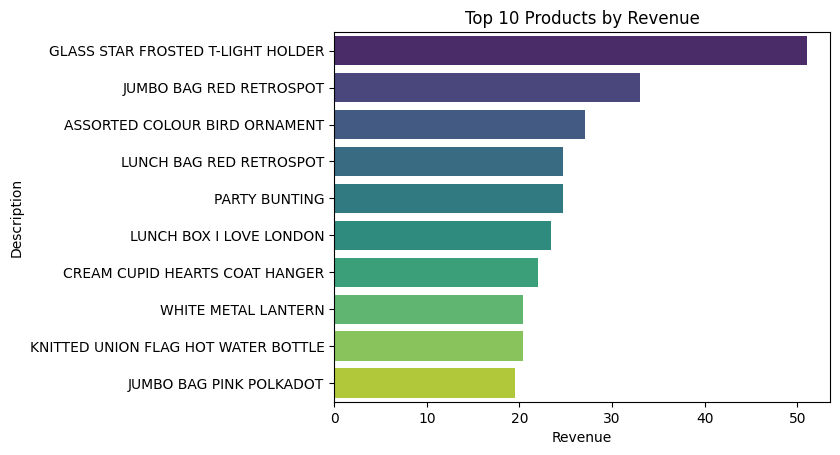

In [17]:
top_product=df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10).reset_index()

plt.Figure(figsize=(8,5))
sns.barplot(data=top_product,y='Description',x='Revenue',palette='viridis')
plt.title("Top 10 Products by Revenue")
plt.show()

**Revenue by Country**

In [27]:
Country_revenue=df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).reset_index()


C:\Users\ASUS\AppData\Local\Temp\ipykernel_17668\3939716768.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=country_revenue, x='Revenue', y='Country',palette='deep')


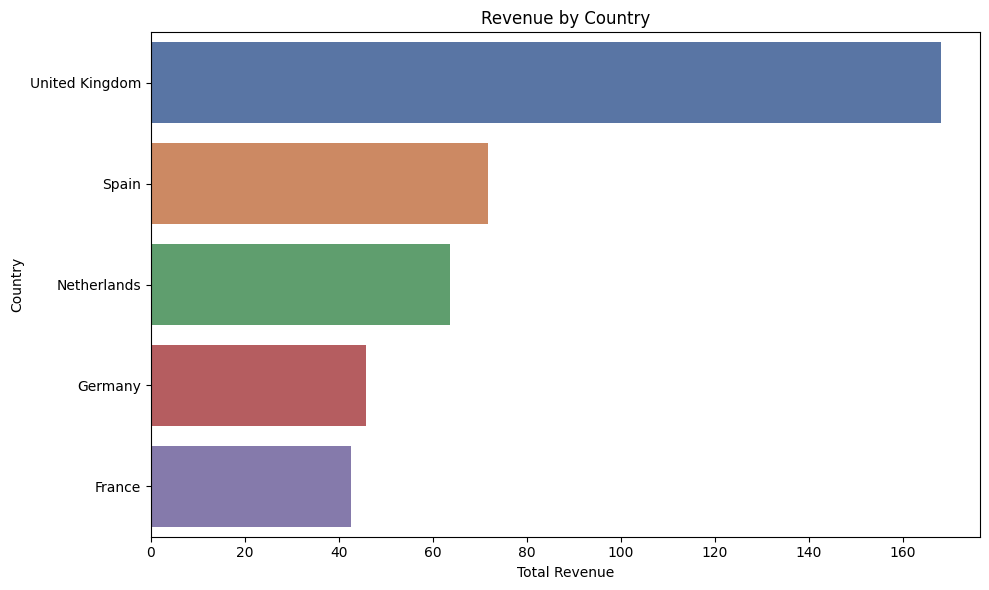

In [31]:
plt.figure(figsize=(10,6))

country_revenue = Country_revenue.sort_values(by='Revenue', ascending=False)

sns.barplot(data=country_revenue, x='Revenue', y='Country',palette='deep')

plt.title("Revenue by Country", fontsize=12)
plt.xlabel("Total Revenue")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

**RFM Segmentation**

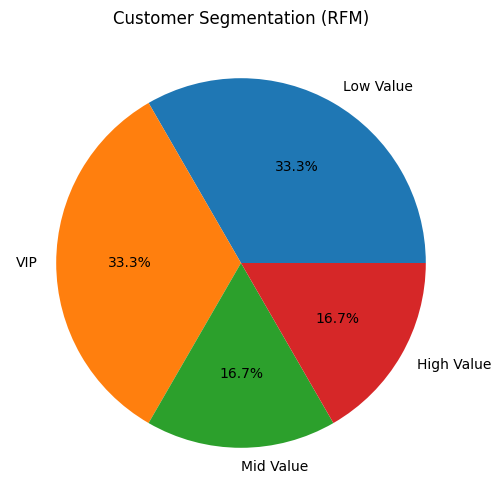

In [39]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (df['InvoiceDate'].max() - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
rfm['Segment'] = pd.qcut(rfm['Monetary'], 4,labels=['Low Value', 'Mid Value', 'High Value', 'VIP'])
segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%')
plt.title("Customer Segmentation (RFM)")
plt.show()


C:\Users\ASUS\AppData\Local\Temp\ipykernel_17668\826897149.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, x='Segment',palette='mako')


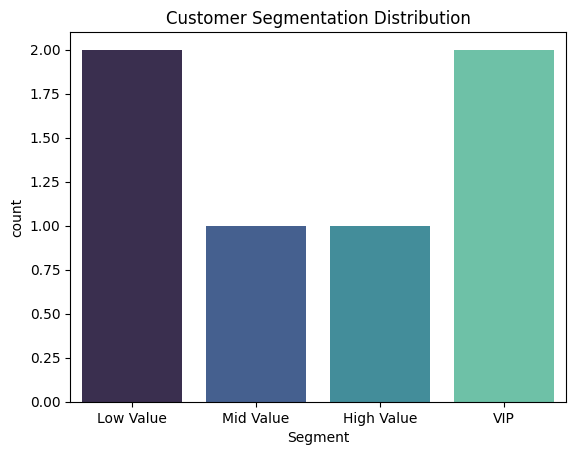

In [37]:
sns.countplot(data=rfm, x='Segment',palette='mako')
plt.title("Customer Segmentation Distribution")
plt.show()